<h1 style="text-align: center;font-weight:bold;">Supply Density in the Order Book</h1>

<p>
In this sample analysis, the objective is to estimate the supply density on both sides of the market and determine whether there is an imbalance between the ask and bid sides of the order book.
</p>

### Import Libraries

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import requests


### Data Gathering

To begin our analysis, we first request the most recent depth information using the Binance Futures REST API. Then, we save the prices and their respective quantities separately for easier downstream analysis.

*\* In this example, we use the ETHUSDT pair.*

In [12]:
# Retrieve the top 20 ask and bid prices and amounts of ETH from Binance Futures API
pair = "ETHUSDT"
depth_info = requests.get(f"https://fapi.binance.com/fapi/v1/depth?symbol={pair}&limit=20").json()

ask_prices = [float(price) for price, amount in depth_info['asks'][:20]]
ask_quantities = [float(amount) for price, amount in depth_info['asks'][:20]]
bid_prices = [float(price) for price, amount in depth_info['bids'][:20]]
bid_quantities = [float(amount) for price, amount in depth_info['bids'][:20]]

### The Analysis

#### Data Accumulation

In order to plot the bids and asks to resemble the supply and demand curves, we accumulate the orders based on the following formula:
$$\sum_{i=1}^{n} q(i)$$
where $q(i)$ is the quantity posted at level $i$.

In [13]:
# Accumulate the bid and ask sizes to calculate cumulative order book depth

cumulative_bid = []

for i in range(len(bid_quantities)):
  cumulative_bid.append(sum(bid_quantities[:i+1]))

cumulative_ask = []

for i in range(len(ask_quantities)):
  cumulative_ask.append(sum(ask_quantities[:i+1]))

#### Plotting the Data

After creating the cumulative data, we check the shape of our order book to see whether it follows a classic supply and demand curve.

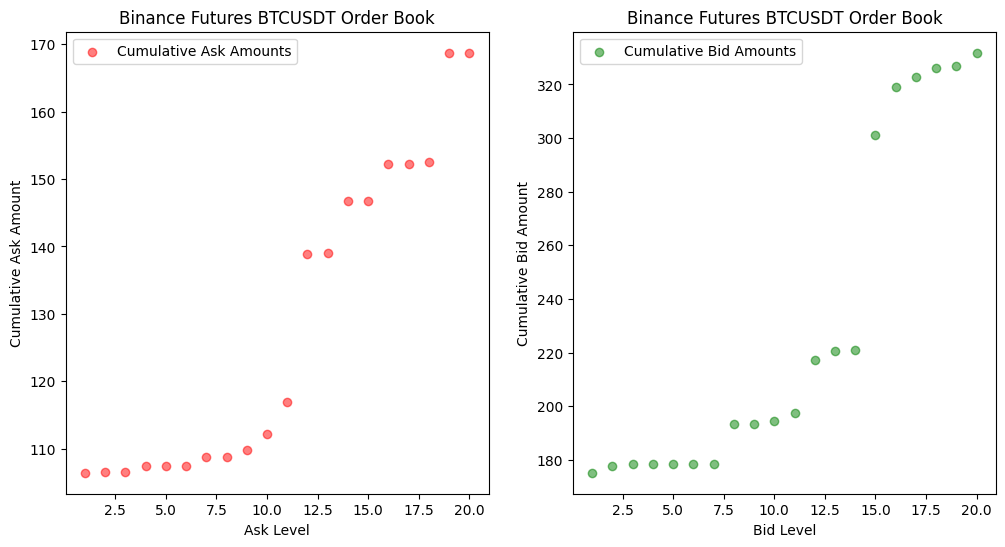

In [14]:
# How is the orderbook distributed? Plot the cumulative ask and bid amounts against their respective levels.


plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(np.arange(1, len(cumulative_ask) + 1), cumulative_ask, color='red', alpha=0.5, label='Cumulative Ask Amounts')
plt.xlabel('Ask Level')
plt.ylabel('Cumulative Ask Amount')
plt.title('Binance Futures BTCUSDT Order Book')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(np.arange(1, len(cumulative_bid) + 1), cumulative_bid, color='green', alpha=0.5, label='Cumulative Bid Amounts')
plt.xlabel('Bid Level')
plt.ylabel('Cumulative Bid Amount')
plt.title('Binance Futures BTCUSDT Order Book')
plt.legend()
plt.show()

#### Adjusting the Graph

After numerous runs, we can observe in the graphs above that the distribution often looks non-linear and exponential. As a result, we use a log graph to linearize the quantity.

Due to the exponential nature of the order book, we plot the log of the cumulative quantity against the levels to see if we can find a linear relationship.

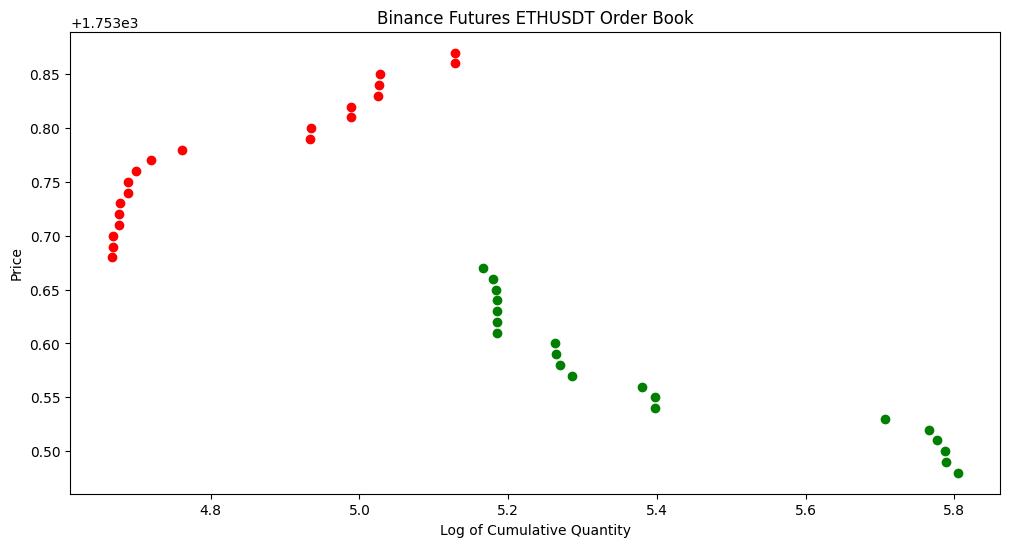

In [15]:
# Plot the cumulative ask and bid amounts against their respective levels on a log scale.

plt.figure(figsize=(12, 6))
plt.scatter(np.log(cumulative_ask), ask_prices, color='red')
plt.xlabel('Log of Cumulative Quantity')
plt.ylabel('Price')
plt.title('Binance Futures ETHUSDT Order Book')

plt.scatter(np.log(cumulative_bid), bid_prices, color='green')
plt.show()

#### Supply Density

After plotting the log of the cumulative quantities against their prices, we can observe a potential linear relationship between the two.

To measure the density, we use the following formula to evaluate how much quantity is available to be taken in a given price range:

$$\text{Density} = \frac{\sum_{i=1}^{n} q(i)}{|p_1 - p_n|}$$

This equation can simply be interpreted as the average rate of change from $p_1$ to $p_n$ on the cumulative quantity-price graph.

*\* Higher density at a given level compared to the opposing side is indicative of maker aggressiveness. In other words, it shows how much makers are willing to post their orders near the best price to increase the probability of getting a fill.*

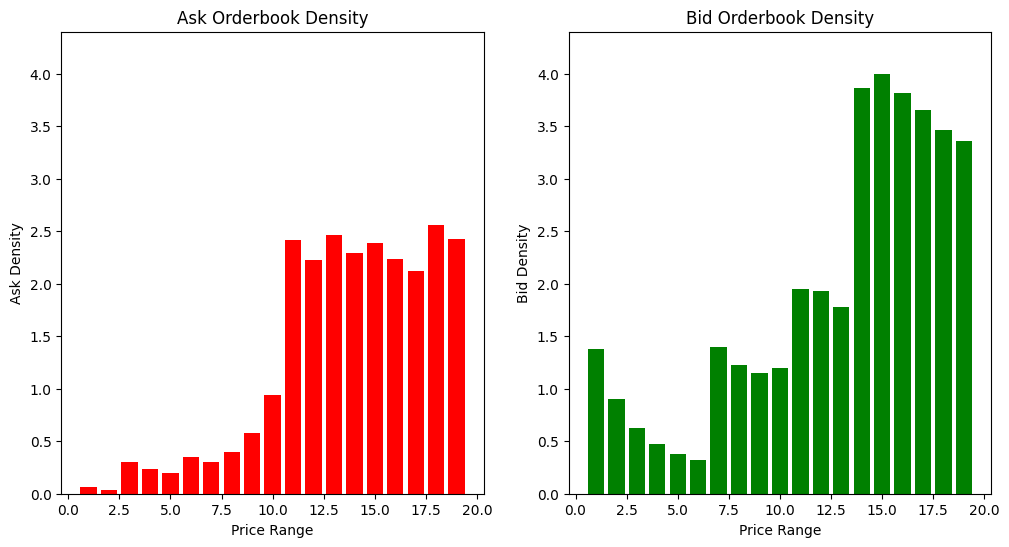

In [16]:

ask_density =[]
for i in range(1, len(ask_prices)):
  ask_density.append((np.log(cumulative_ask[i]) - np.log(cumulative_ask[0])) / (ask_prices[i] - ask_prices[0]))

bid_density =[]
for i in range(1, len(bid_prices)):
  bid_density.append((np.log(cumulative_bid[i]) - np.log(cumulative_bid[0])) / (bid_prices[0] - bid_prices[i]))



plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.bar(np.arange(1, len(ask_density)+1), ask_density, color='red')
plt.xlabel('Price Range')
plt.ylabel('Ask Density')
plt.ylim(0, max(max(ask_density), max(bid_density)) * 1.1)
plt.title('Ask Orderbook Density')

plt.subplot(1, 2, 2)
plt.bar(np.arange(1, len(bid_density)+1), bid_density, color='green')
plt.xlabel('Price Range')
plt.ylabel('Bid Density')
plt.title('Bid Orderbook Density')
plt.ylim(0, max(max(ask_density), max(bid_density)) * 1.1)
plt.show()

#### Instantaneous Density

As observed in the graphs above, the density of the order book tends to increase as the price range expands, due to the exponential nature of the quantities posted. Although the original formula gives us the overall density at each level, it does not provide information regarding how that density changes as it moves to deeper levels. As a result, measuring the instantaneous density of the order book gives us a better understanding of the rate of change and the willingness of makers to trade at each level.

In order to calculate the instantaneous density, we modify the original formula as follows:

$$\text{Instantaneous Density} = \frac{\log(\text{cq}_i) - \log(\text{cq}_{i-1})}{|p_i - p_{i-1}|}$$

where $\text{cq}_i$ is the cumulative quantity at level $i$.

If the instantaneous rate of one side has a flatter slope, it can mean one of two things:
1. **Fully Aggressive:** The market maker has already posted most of their orders near the best price.
2. **Fully Passive:** The market maker is not willing to accumulate orders on that side.

In this case, utilizing the overall density formula becomes crucial to distinguishing between these two scenarios.

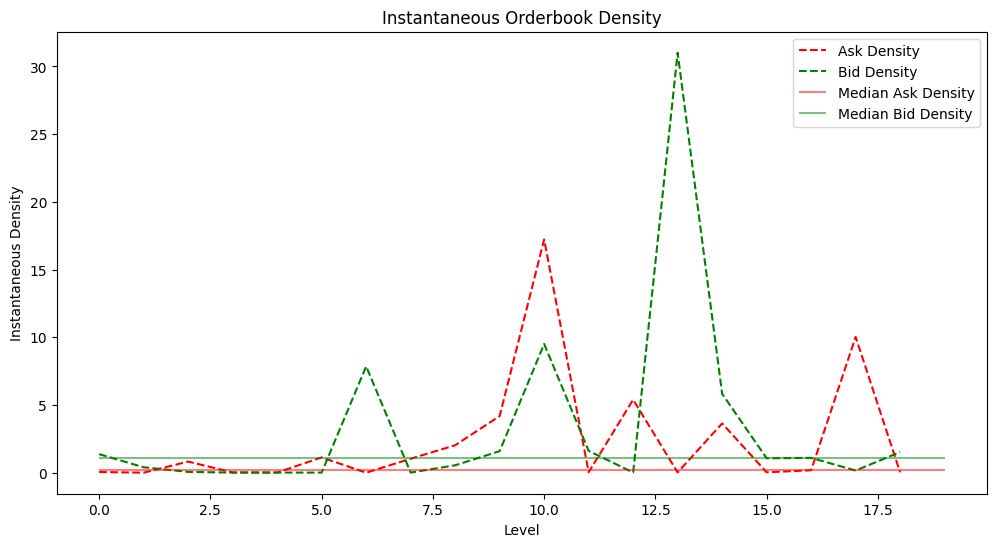

In [17]:
# Track the instantaneous density of the orderbook at each level and plot it against the level. Additionally, plot the median of the instantaneous density for both ask and bid sides.

inst_ask_density=[]
inst_bid_density=[]
for i in range(1, len(ask_prices)):
    inst_ask_density.append((np.log(cumulative_ask[i]) - np.log(cumulative_ask[i-1])) / (ask_prices[i] - ask_prices[i-1]))
    inst_bid_density.append((np.log(cumulative_bid[i]) - np.log(cumulative_bid[i-1])) / (bid_prices[i-1] - bid_prices[i]))

plt.figure(figsize=(12, 6))
plt.plot(np.arange(len(inst_ask_density)), inst_ask_density, color='red', ls='--')
plt.plot(np.arange(len(inst_bid_density)), inst_bid_density, color='green', ls='--')
plt.hlines(y=np.median(inst_ask_density), xmin=0, xmax=len(inst_ask_density), color='red', ls='-', alpha=0.5)
plt.hlines(y=np.median(inst_bid_density), xmin=0, xmax=len(inst_bid_density), color='green', ls='-', alpha=0.5)
plt.xlabel('Level')
plt.ylabel('Instantaneous Density')
plt.title('Instantaneous Orderbook Density')
plt.legend(['Ask Density', 'Bid Density', 'Median Ask Density', 'Median Bid Density'])
plt.show()

#### Noise Cleaning

As we can observe from the graph, the instantaneous density often looks noisy. This occurs because the distribution of orders is skewed toward the nearest clusters for profit maximization, leaving many price levels empty or low in quantity. 

To clear this noise from the data, we implement a more robust approach. Instead of calculating the density across all raw orders, we filter out any levels with quantities falling below the average log quantity. We then calculate the mean distance between the remaining active clusters.

*\* For simplicity, we assume that all orders will be filled entirely, and that this is the only batch of orders traded within the given interval.*

In [18]:
# Find the orders that pass the mean log of quantity.
mean_ask_log_sum = {"numerator": 0, "denominator": 0, "mean_log": 0}
mean_bid_log_sum = {"numerator": 0, "denominator": 0, "mean_log": 0}

for i in range(len(ask_quantities)):
    mean_ask_log_sum["numerator"] += np.log(ask_quantities[i])
    mean_ask_log_sum["denominator"] += 1

if mean_ask_log_sum["denominator"] > 0:
    mean_ask_log_sum["mean_log"] = mean_ask_log_sum["numerator"] / mean_ask_log_sum["denominator"]

for i in range(len(bid_quantities)):
    mean_bid_log_sum["numerator"] += np.log(bid_quantities[i])
    mean_bid_log_sum["denominator"] += 1

if mean_bid_log_sum["denominator"] > 0:
    mean_bid_log_sum["mean_log"] = mean_bid_log_sum["numerator"] / mean_bid_log_sum["denominator"]

# Sieve the orders that pass the mean log of quantity
# To filter the orders that pass the mean log of quantity, we use a thresholding technique. We will iterate through the ask and bid quantities and check if their logarithm is greater than the mean log of quantity.
# If it is, we will add them to a filtered list.
# Additionally, we use the same starting price for both sides to standardize the price differences.


filtered_ask_prices = []
last_ask_price = 0
filtered_bid_prices = []
last_bid_price = 0

for i in range(len(ask_quantities)):
    if np.log(ask_quantities[i]) > mean_ask_log_sum["mean_log"]:
        if last_ask_price == 0:
            filtered_ask_prices.append(last_ask_price)
        else:
            filtered_ask_prices.append(filtered_ask_prices[-1] + (ask_prices[i] - last_ask_price))
        last_ask_price=ask_prices[i]
for i in range(len(bid_quantities)):
    if np.log(bid_quantities[i]) > mean_bid_log_sum["mean_log"]:
        if last_bid_price == 0:
            filtered_bid_prices.append(last_bid_price)
        else:
            filtered_bid_prices.append(filtered_bid_prices[-1] + (last_bid_price - bid_prices[i]))
        last_bid_price=bid_prices[i]


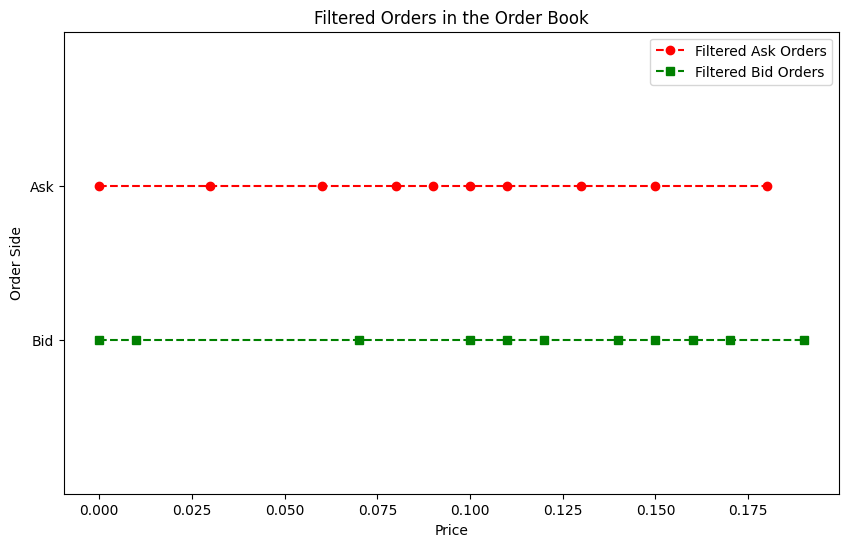

In [19]:
# Plot the filtered orders
plt.figure(figsize=(10, 6))

plt.plot(filtered_ask_prices, [1]*len(filtered_ask_prices), color='red', label='Filtered Ask Orders', marker='o', linestyle='--')
plt.plot(filtered_bid_prices, [0.5]*len(filtered_bid_prices), color='green', label='Filtered Bid Orders', marker='s', linestyle='--')

plt.yticks([0.5, 1], ['Bid', 'Ask'])
plt.ylim(0, 1.5)

plt.xlabel('Price')
plt.ylabel('Order Side') 
plt.title('Filtered Orders in the Order Book')
plt.legend()
plt.show()

### Final Result

Finally, we calculate the mean distance of each order that passed the mean log of quantity from the best bid and ask prices. This gives us an idea of how far these significant orders are from the current market price, which can be useful for understanding potential market movements and liquidity.

Statistically, the mean distance for BTCUSDT has been below 0.7. As a result, seeing a mean distance above or near that threshold can be an indication of a potential inventory imbalance faced by market makers.

This technique shows only a possible inventory imbalance in the market. No matter on which side of the book this phenomenon has been observed, using this technique, we cannot predict the market direction. It is only a tool to help us understand the potential liquidity issues. For the direction of the market, we need to use other techniques such as premium analysis, borrow rate analysis, and funding rate analysis.

In [20]:
minimum_distance_threshold = 0.7

ask_distance = {"numerator": 0, "denominator": 0, "mean_distance": 0}
bid_distance = {"numerator": 0, "denominator": 0, "mean_distance": 0}

for i in range(1, len(filtered_ask_prices)):
    ask_distance["numerator"] += abs(filtered_ask_prices[i] - filtered_ask_prices[i-1])
    ask_distance["denominator"] += 1
for i in range(1, len(filtered_bid_prices)):
    bid_distance["numerator"] += abs(filtered_bid_prices[i] - filtered_bid_prices[i-1])
    bid_distance["denominator"] += 1

if ask_distance["denominator"] > 0:
    ask_distance["mean_distance"] = ask_distance["numerator"] / ask_distance["denominator"]

if bid_distance["denominator"] > 0:
    bid_distance["mean_distance"] = bid_distance["numerator"] / bid_distance["denominator"]


# Output the final results
if len(filtered_ask_prices) == 0:
    print("No filtered ask orders found.")
else:
    print(f"Mean distance of filtered ask orders: {ask_distance['mean_distance']:.2f} | Passed threshold: {ask_distance['mean_distance'] > minimum_distance_threshold}")
if len(filtered_bid_prices) == 0:
    print("No filtered bid orders found.")
else:
    print(f"Mean distance of filtered bid orders: {bid_distance['mean_distance']:.2f} | Passed threshold: {bid_distance['mean_distance'] > minimum_distance_threshold}")

Mean distance of filtered ask orders: 0.02 | Passed threshold: False
Mean distance of filtered bid orders: 0.02 | Passed threshold: False
